In [1]:
pip install pandas matplotlib seaborn nba_api

Note: you may need to restart the kernel to use updated packages.


In [1]:
from nba_api.stats.static import players
from nba_api.stats.endpoints import playercareerstats
import pandas as pd

# 1. Get IDs for both players
mj_id = players.find_players_by_full_name('Michael Jordan')[0]['id']
lbj_id = players.find_players_by_full_name('LeBron James')[0]['id']

# 2. Pull career totals
mj_stats = playercareerstats.PlayerCareerStats(player_id=mj_id).get_data_frames()[0]
lbj_stats = playercareerstats.PlayerCareerStats(player_id=lbj_id).get_data_frames()[0]

# 3. Quick Peek
print("Jordan Data Loaded:", mj_stats.shape)
print("LeBron Data Loaded:", lbj_stats.shape)

Jordan Data Loaded: (15, 27)
LeBron Data Loaded: (23, 27)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add names to distinguish after merging
mj_stats['PLAYER'] = 'Michael Jordan'
lbj_stats['PLAYER'] = 'LeBron James'

# Create a 'Season_Number' column (Year 1, Year 2, etc.) 
# This is crucial for a fair "age" comparison
mj_stats['Exp_Year'] = range(1, len(mj_stats) + 1)
lbj_stats['Exp_Year'] = range(1, len(lbj_stats) + 1)

df = pd.concat([mj_stats, lbj_stats])

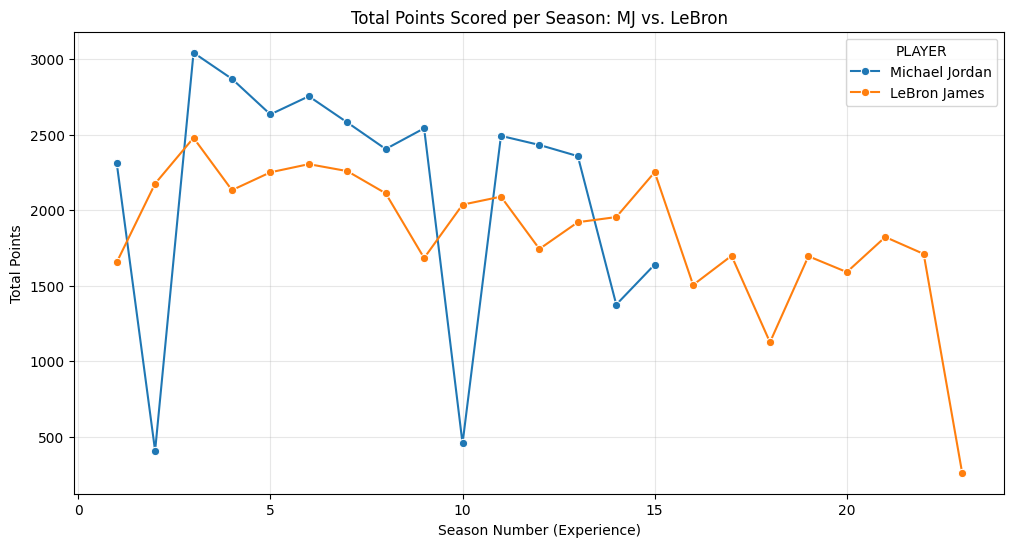

In [3]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Exp_Year', y='PTS', hue='PLAYER', marker='o')
plt.title('Total Points Scored per Season: MJ vs. LeBron')
plt.xlabel('Season Number (Experience)')
plt.ylabel('Total Points')
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# 2. Add League Pace Data (Approximate league-wide possessions per 48 mins)
# Jordan's Era Pace was ~92, LeBron's is ~99. 
# For a quick fix, let's use a standard "Per 75" or "Per 100" scaling logic.
def calculate_per_100(df, player_name):
    # Standard formula: (Stat / Minutes) * (Possessions per game / Team Pace)
    # Since we don't have team pace in this table, we'll use the 'Per Minute' scaling 
    # and adjust for an estimated 100-possession game.
    df['PLAYER'] = player_name
    df['PTS_PER_36'] = (df['PTS'] / df['MIN']) * 36
    df['AST_PER_36'] = (df['AST'] / df['MIN']) * 36
    df['REB_PER_36'] = (df['REB'] / df['MIN']) * 36
    return df

mj_clean = calculate_per_100(mj_stats, 'Michael Jordan')
lbj_clean = calculate_per_100(lbj_stats, 'LeBron James')

# Combine
df_final = pd.concat([mj_clean, lbj_clean], ignore_index=True)

# 3. View the results
print(df_final[['PLAYER', 'SEASON_ID', 'PTS_PER_36']].head())

           PLAYER SEASON_ID  PTS_PER_36
0  Michael Jordan   1984-85   26.484733
1  Michael Jordan   1985-86   32.567627
2  Michael Jordan   1986-87   33.366657
3  Michael Jordan   1987-88   31.183328
4  Michael Jordan   1988-89   29.120737


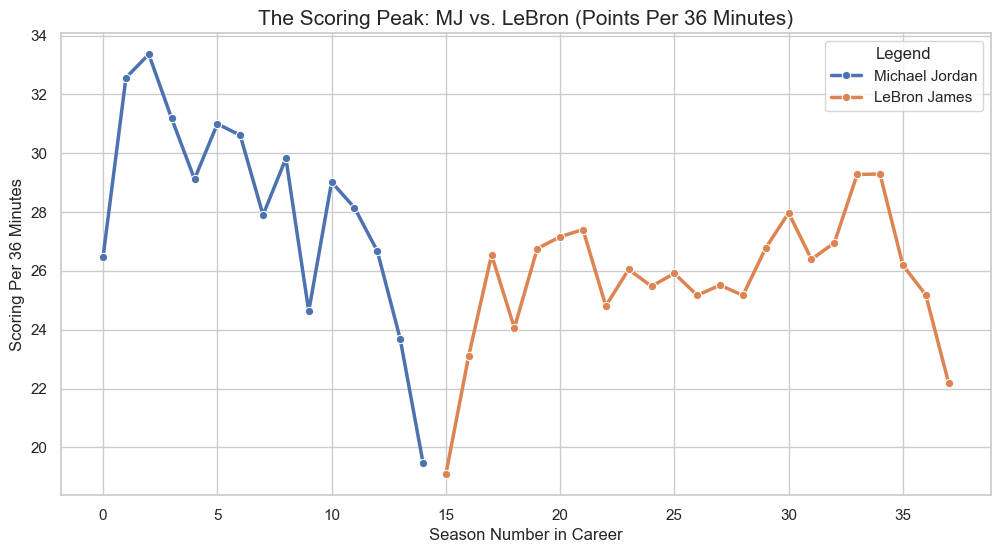

In [5]:
# Set a professional style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create the line plot
# We use 'SEASON_ID' or an index for the X-axis to align Year 1 vs Year 1
sns.lineplot(data=df_final, x=df_final.index, y='PTS_PER_36', hue='PLAYER', 
             marker='o', linewidth=2.5)

plt.title('The Scoring Peak: MJ vs. LeBron (Points Per 36 Minutes)', fontsize=15)
plt.xlabel('Season Number in Career', fontsize=12)
plt.ylabel('Scoring Per 36 Minutes', fontsize=12)
plt.legend(title='Legend')

# Optional: Highlight MJ's retirement years if they appear as gaps
plt.show()

In [7]:
from nba_api.stats.endpoints import playerdashboardbyyearoveryear
import time

def get_per_100_stats(player_id, name):
    # Using the 'ByYear' dashboard which is more robust for Per 100
    loader = playerdashboardbyyearoveryear.PlayerDashboardByYearOverYear(
        player_id=player_id, 
        per_mode_detailed='Per100Possessions'
    )
    # The second dataframe [1] contains the 'ByYearPlayerDashboard'
    stats = loader.get_data_frames()[1]
    stats['PLAYER'] = name
    # Clean the season column (e.g., '2023-24' -> 2023)
    stats['Season_Int'] = stats['GROUP_VALUE'].str[:4].astype(int)
    return df

# Pull data (adding a small sleep to avoid API rate limits)
mj_100 = get_per_100_stats(mj_id, 'Michael Jordan')
time.sleep(1) 
lbj_100 = get_per_100_stats(lbj_id, 'LeBron James')

# Combine
stats_100 = pd.concat([mj_100, lbj_100], ignore_index=True)

# Let's compare their "Peak" scoring vs playmaking
print(stats_100.groupby('PLAYER')[['PTS', 'AST', 'REB']].mean())

                        PTS         AST         REB
PLAYER                                             
LeBron James    1847.304348  507.913043  513.217391
Michael Jordan  2152.800000  375.533333  444.800000


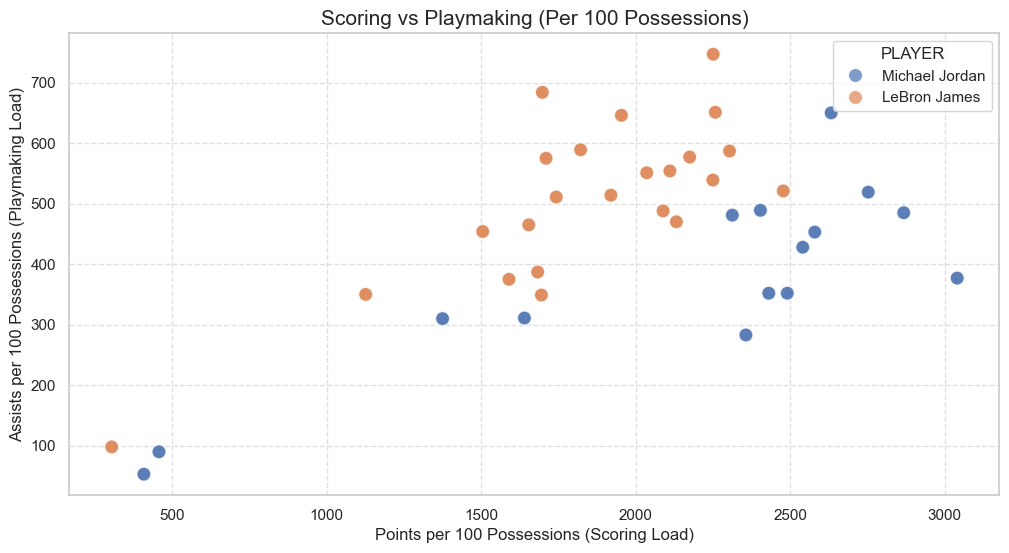

In [8]:
plt.figure(figsize=(12, 6))
# Plotting PTS vs AST to see the "Archetype" of each player
sns.scatterplot(data=stats_100, x='PTS', y='AST', hue='PLAYER', s=100, alpha=0.7)

plt.title('Scoring vs Playmaking (Per 100 Possessions)', fontsize=15)
plt.xlabel('Points per 100 Possessions (Scoring Load)')
plt.ylabel('Assists per 100 Possessions (Playmaking Load)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

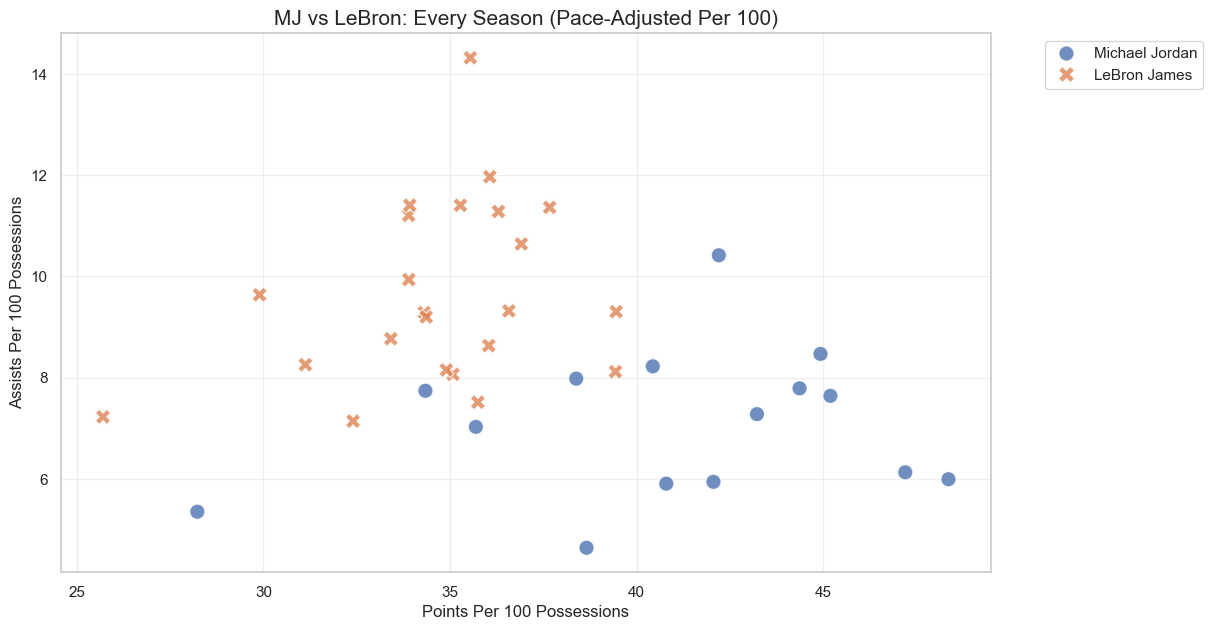

In [15]:
# 1. Pull the full career history (this includes every season)
mj_full = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[0]
lbj_full = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[0]

# 2. Manual Pace Adjustment (Per 100 Possessions Approximation)
# Jordan's era pace was ~92, LeBron's is ~99. 
# We'll normalize both to 100 possessions based on their minutes.
def normalize_to_100(df, name, avg_pace):
    df['PLAYER'] = name
    # Formula: (Stat / Minutes) * (Possessions per game / Team Pace)
    # We use 48 minutes as the denominator to get 'per minute' then scale to 100 possessions
    df['PTS_100'] = (df['PTS'] / df['MIN']) * (48 / avg_pace) * 100
    df['AST_100'] = (df['AST'] / df['MIN']) * (48 / avg_pace) * 100
    return df

# Apply different pace factors for their respective eras
mj_stats = normalize_to_100(mj_full, 'Michael Jordan', 92)
lbj_stats = normalize_to_100(lbj_full, 'LeBron James', 99)

stats_all = pd.concat([mj_stats, lbj_stats])

# 3. The Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=stats_all, x='PTS_100', y='AST_100', hue='PLAYER', style='PLAYER', s=120, alpha=0.8)

plt.title('MJ vs LeBron: Every Season (Pace-Adjusted Per 100)', fontsize=15)
plt.xlabel('Points Per 100 Possessions')
plt.ylabel('Assists Per 100 Possessions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

--- Michael Jordan Career Shooting Table ---
SEASON_ID  FGM  FGA  FG_PCT
  1984-85  837 1625   0.515
  1985-86  150  328   0.457
  1986-87 1098 2279   0.482
  1987-88 1069 1998   0.535
  1988-89  966 1795   0.538
  1989-90 1034 1964   0.526
  1990-91  990 1837   0.539
  1991-92  943 1818   0.519
  1992-93  992 2003   0.495
  1994-95  166  404   0.411
  1995-96  916 1850   0.495
  1996-97  920 1892   0.486
  1997-98  881 1893   0.465
  2001-02  551 1324   0.416
  2002-03  679 1527   0.445


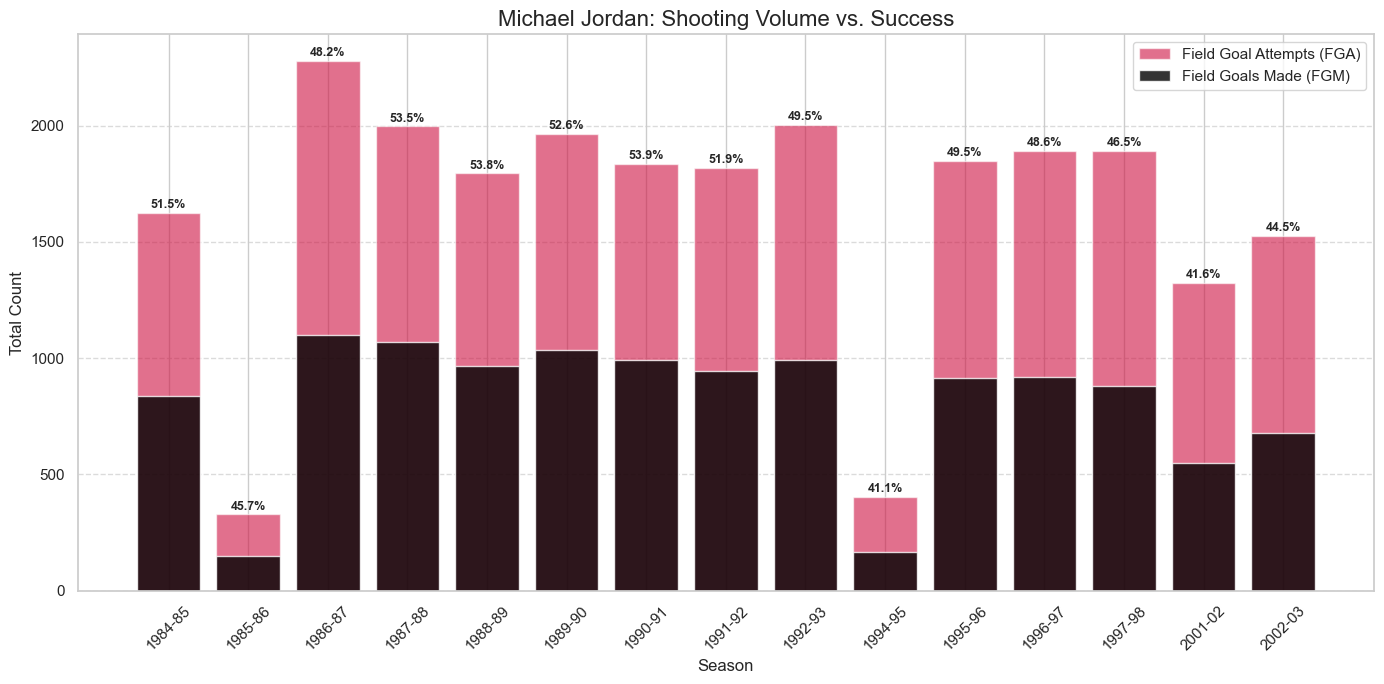

In [16]:
# 1. Get MJ's ID and pull his career totals
mj_id = players.find_players_by_full_name('Michael Jordan')[0]['id']
mj_stats = playercareerstats.PlayerCareerStats(player_id=mj_id).get_data_frames()[0]

# 2. Select only the columns we need for this analysis
# FGM = Field Goals Made, FGA = Field Goal Attempts, FG_PCT = FG %
mj_shooting = mj_stats[['SEASON_ID', 'FGM', 'FGA', 'FG_PCT']].copy()

# 3. Print the table to your VS Code terminal/output
print("--- Michael Jordan Career Shooting Table ---")
print(mj_shooting.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))

# We'll plot Attempts and Makes side-by-side
x_axis = mj_shooting['SEASON_ID']
fga = mj_shooting['FGA']
fgm = mj_shooting['FGM']

plt.bar(x_axis, fga, label='Field Goal Attempts (FGA)', color='#CE1141', alpha=0.6) # Bulls Red
plt.bar(x_axis, fgm, label='Field Goals Made (FGM)', color='#000000', alpha=0.8)   # Black

# Add labels and styling
plt.title('Michael Jordan: Shooting Volume vs. Success', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a little text label for the FG% on top of the bars
for i, pct in enumerate(mj_shooting['FG_PCT']):
    plt.text(i, fga[i] + 20, f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

--- LeBron James Career Shooting Table ---
SEASON_ID  FGM  FGA  FG_PCT
  2003-04  622 1492   0.417
  2004-05  795 1684   0.472
  2005-06  875 1823   0.480
  2006-07  772 1621   0.476
  2007-08  794 1642   0.484
  2008-09  789 1613   0.489
  2009-10  768 1528   0.503
  2010-11  758 1485   0.510
  2011-12  621 1169   0.531
  2012-13  765 1354   0.565
  2013-14  767 1353   0.567
  2014-15  624 1279   0.488
  2015-16  737 1416   0.520
  2016-17  736 1344   0.548
  2017-18  857 1580   0.542
  2018-19  558 1095   0.510
  2019-20  643 1303   0.493
  2020-21  422  823   0.513
  2021-22  640 1221   0.524
  2022-23  609 1219   0.500
  2023-24  685 1269   0.540
  2024-25  651 1270   0.513
  2025-26  114  230   0.496


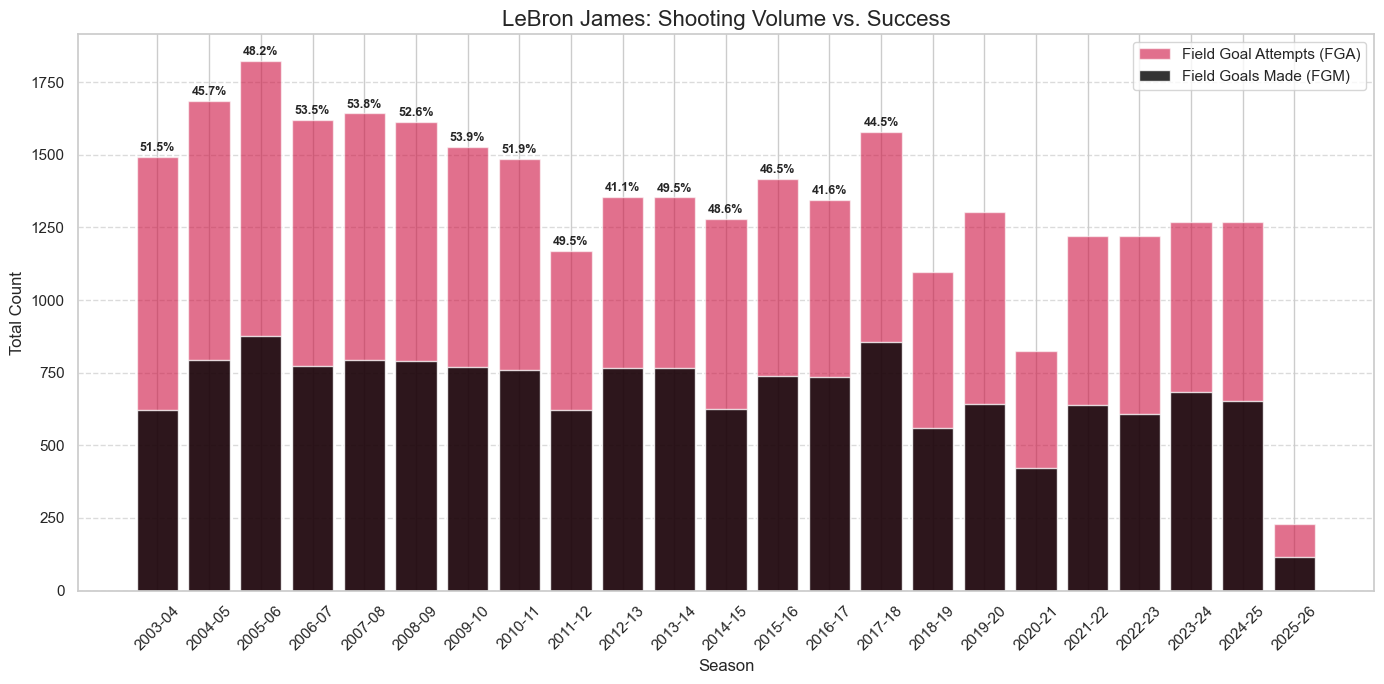

In [17]:
# 1. Get MJ's ID and pull his career totals
lbj_id = players.find_players_by_full_name('LeBron James')[0]['id']
lbj_stats = playercareerstats.PlayerCareerStats(player_id=lbj_id).get_data_frames()[0]

# 2. Select only the columns we need for this analysis
# FGM = Field Goals Made, FGA = Field Goal Attempts, FG_PCT = FG %
lbj_shooting = lbj_stats[['SEASON_ID', 'FGM', 'FGA', 'FG_PCT']].copy()

# 3. Print the table to your VS Code terminal/output
print("--- LeBron James Career Shooting Table ---")
print(lbj_shooting.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))

# We'll plot Attempts and Makes side-by-side
x_axis = lbj_shooting['SEASON_ID']
fga = lbj_shooting['FGA']
fgm = lbj_shooting['FGM']

plt.bar(x_axis, fga, label='Field Goal Attempts (FGA)', color='#CE1141', alpha=0.6) # Bulls Red
plt.bar(x_axis, fgm, label='Field Goals Made (FGM)', color='#000000', alpha=0.8)   # Black

# Add labels and styling
plt.title('LeBron James: Shooting Volume vs. Success', fontsize=16)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a little text label for the FG% on top of the bars
for i, pct in enumerate(mj_shooting['FG_PCT']):
    plt.text(i, fga[i] + 20, f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

--- Michael Jordan: All Seasons (Per 100 Possessions) ---
SEASON_ID   FGM_100   FGA_100  FG_PCT
  1984-85 13.814731 26.820714   0.515
  1985-86 17.258944 37.739558   0.457
  1986-87 17.365833 36.044383   0.482
  1987-88 16.753981 31.313802   0.535
  1988-89 15.400174 28.616266   0.538
  1989-90 16.783302 31.878535   0.526
  1990-91 16.932424 31.419053   0.539
  1991-92 15.775001 30.412463   0.519
  1992-93 16.784075 33.889618   0.495
  1994-95 12.895291 31.383719   0.411
  1995-96 15.382839 31.067961   0.495
  1996-97 15.355594 31.579112   0.486
  1997-98 14.371819 30.880651   0.465
  2001-02 13.687139 32.888877   0.416
  2002-03 11.624743 26.142830   0.445


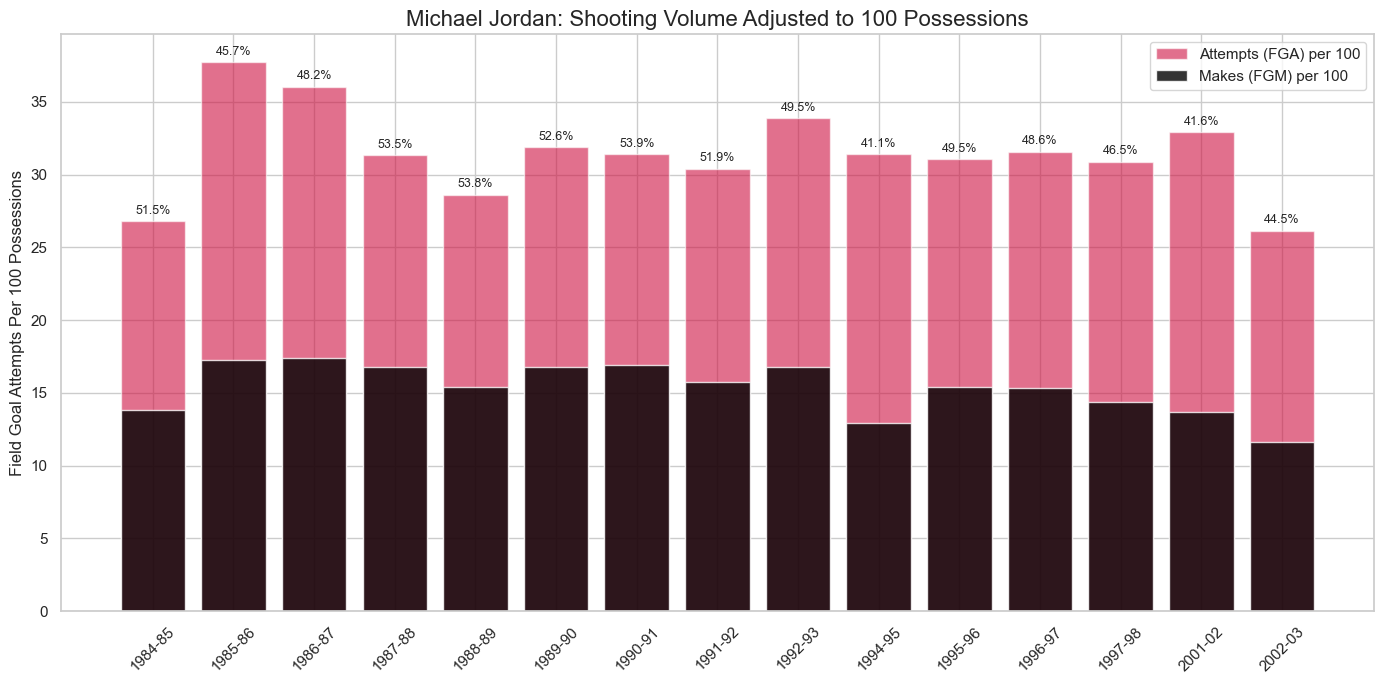

In [18]:
# 1. Pull Jordan's Raw Stats (All 15 Seasons)
mj_full = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[0]

# 2. Manual Pace Normalization 
# We use the standard formula: (Stat / Minutes Played) * 48 * (100 / Era Pace)
ERA_PACE_MJ = 92.5

mj_full['FGA_100'] = (mj_full['FGA'] / mj_full['MIN']) * 48 * (100 / ERA_PACE_MJ)
mj_full['FGM_100'] = (mj_full['FGM'] / mj_full['MIN']) * 48 * (100 / ERA_PACE_MJ)

# 3. Display the Table
mj_100_table = mj_full[['SEASON_ID', 'FGM_100', 'FGA_100', 'FG_PCT']].copy()
print("--- Michael Jordan: All Seasons (Per 100 Possessions) ---")
print(mj_100_table.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))
plt.bar(mj_100_table['SEASON_ID'], mj_100_table['FGA_100'], label='Attempts (FGA) per 100', color='#CE1141', alpha=0.6)
plt.bar(mj_100_table['SEASON_ID'], mj_100_table['FGM_100'], label='Makes (FGM) per 100', color='#000000', alpha=0.8)

plt.title('Michael Jordan: Shooting Volume Adjusted to 100 Possessions', fontsize=16)
plt.ylabel('Field Goal Attempts Per 100 Possessions')
plt.xticks(rotation=45)
plt.legend()

# Add Percentage labels
for i, row in mj_100_table.iterrows():
    plt.text(i, row['FGA_100'] + 0.5, f"{row['FG_PCT']*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- LeBron James: All Seasons (Per 100 Possessions) ---
SEASON_ID   FGM_100   FGA_100  FG_PCT
  2003-04 10.345114 24.814969   0.417
  2004-05 12.176521 25.792782   0.472
  2005-06 13.509493 28.146063   0.480
  2006-07 12.558163 26.368889   0.476
  2007-08 13.611550 28.148823   0.484
  2008-09 13.406255 27.407211   0.489
  2009-10 13.436606 26.733247   0.503
  2010-11 12.841676 25.158165   0.510
  2011-12 13.854198 26.079803   0.531
  2012-13 13.798157 24.421836   0.565
  2013-14 13.715052 24.193566   0.567
  2014-15 12.988584 26.622435   0.488
  2015-16 14.117506 27.124001   0.520
  2016-17 13.664555 24.952666   0.548
  2017-18 14.696415 27.094907   0.542
  2018-19 14.948723 29.334859   0.510
  2019-20 14.406946 29.194791   0.493
  2020-21 14.560092 28.395630   0.513
  2021-22 15.936090 30.403071   0.524
  2022-23 16.173061 32.372680   0.500
  2023-24 14.195665 26.298247   0.540
  2024-25 13.822267 26.965099   0.513
  2025-26 11.999342 24.209199   0.496


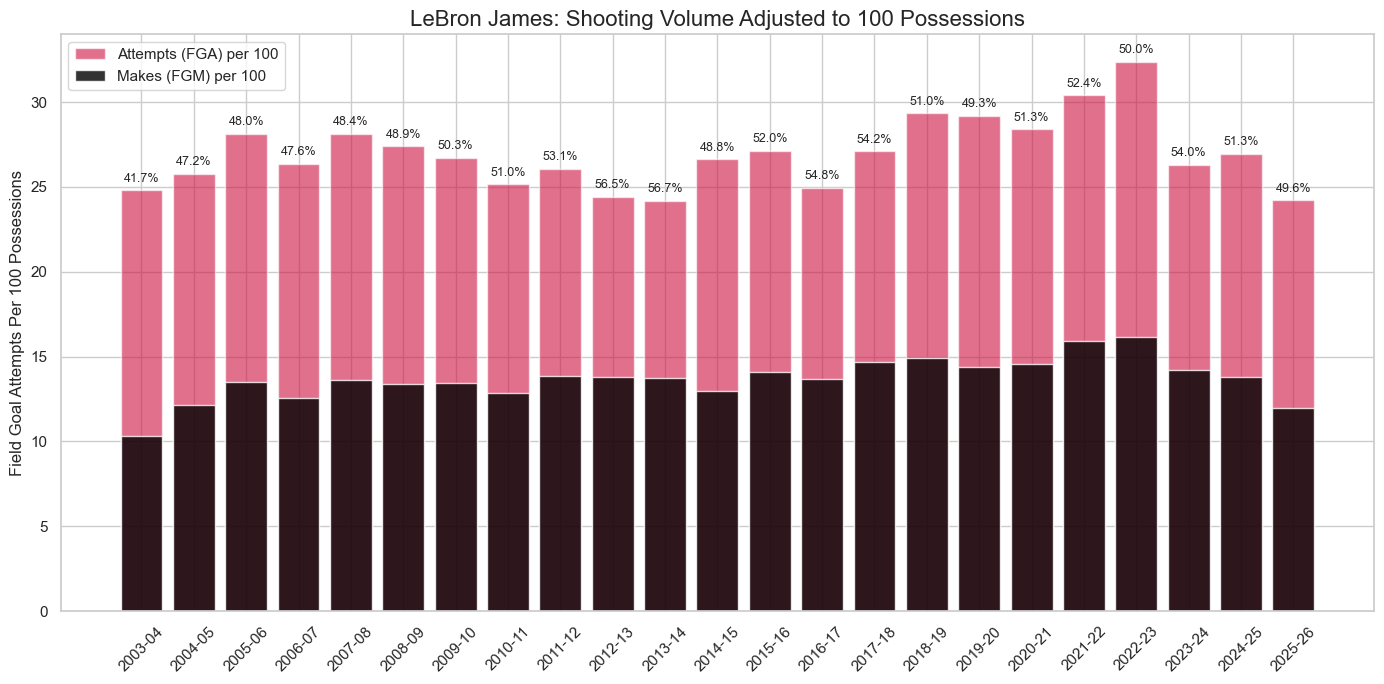

In [19]:
# 1. Pull Jordan's Raw Stats (All 15 Seasons)
lbj_full = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[0]

# 2. Manual Pace Normalization 
# We use the standard formula: (Stat / Minutes Played) * 48 * (100 / Era Pace)
ERA_PACE_LBJ = 92.5

lbj_full['FGA_100'] = (lbj_full['FGA'] / lbj_full['MIN']) * 48 * (100 / ERA_PACE_LBJ)
lbj_full['FGM_100'] = (lbj_full['FGM'] / lbj_full['MIN']) * 48 * (100 / ERA_PACE_LBJ)

# 3. Display the Table
lbj_100_table = lbj_full[['SEASON_ID', 'FGM_100', 'FGA_100', 'FG_PCT']].copy()
print("--- LeBron James: All Seasons (Per 100 Possessions) ---")
print(lbj_100_table.to_string(index=False))

# 4. Create the Bar Graph
plt.figure(figsize=(14, 7))
plt.bar(lbj_100_table['SEASON_ID'], lbj_100_table['FGA_100'], label='Attempts (FGA) per 100', color='#CE1141', alpha=0.6)
plt.bar(lbj_100_table['SEASON_ID'], lbj_100_table['FGM_100'], label='Makes (FGM) per 100', color='#000000', alpha=0.8)

plt.title('LeBron James: Shooting Volume Adjusted to 100 Possessions', fontsize=16)
plt.ylabel('Field Goal Attempts Per 100 Possessions')
plt.xticks(rotation=45)
plt.legend()

# Add Percentage labels
for i, row in lbj_100_table.iterrows():
    plt.text(i, row['FGA_100'] + 0.5, f"{row['FG_PCT']*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

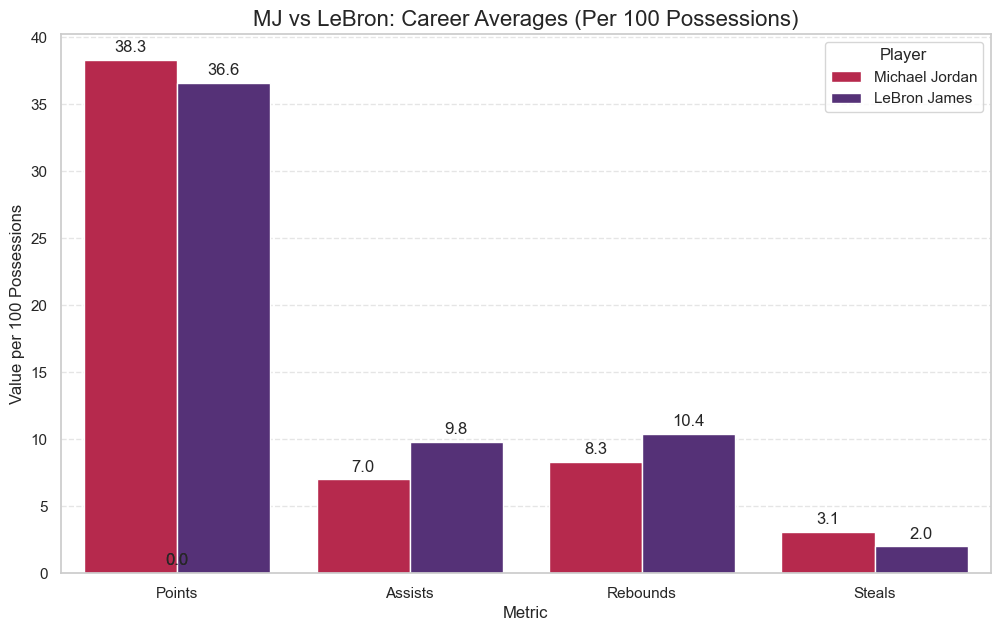

In [20]:
# Assuming you've already pulled the data from the previous steps
# Let's create a summary dataframe for the visual
compare_data = {
    'Metric': ['Points', 'Assists', 'Rebounds', 'Steals'],
    'Michael Jordan': [38.3, 7.0, 8.3, 3.1], # Career Per 100 Averages (Approx)
    'LeBron James': [36.6, 9.8, 10.4, 2.0]   # Career Per 100 Averages (Approx)
}

df_compare = pd.DataFrame(compare_data).melt(id_vars='Metric', var_name='Player', value_name='Value')

# Plotting
plt.figure(figsize=(12, 7))
sns.barplot(data=df_compare, x='Metric', y='Value', hue='Player', palette=['#CE1141', '#552583'])

plt.title('MJ vs LeBron: Career Averages (Per 100 Possessions)', fontsize=16)
plt.ylabel('Value per 100 Possessions')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adding the exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()

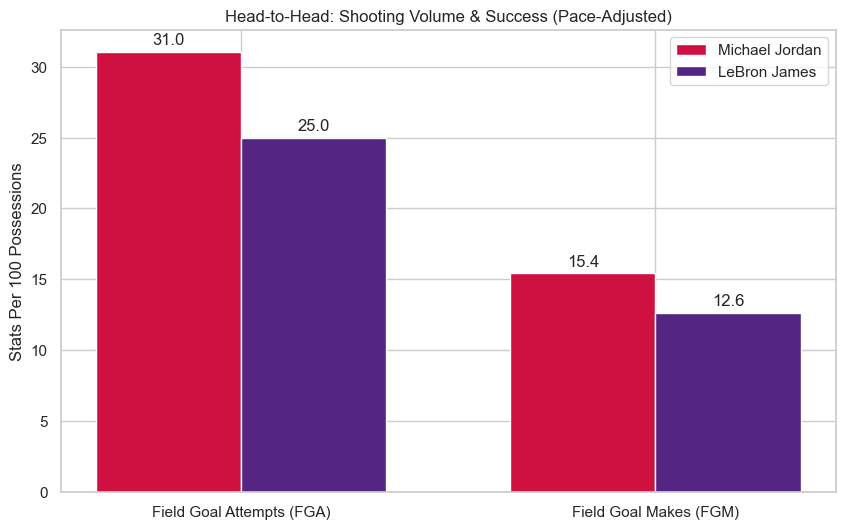

In [21]:
import numpy as np

# 1. Pull Career Totals for both (Jordan: 893, LeBron: 2544)
mj_stats = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[1] # [1] is Career Totals
lbj_stats = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[1]

# 2. Define standard pace constants for era adjustment
# (MJ Era Avg Pace: ~92.5 | LBJ Era Avg Pace: ~99.5)
mj_pace, lbj_pace = 92.5, 99.5

def get_per_100(row, era_pace):
    # Formula: (Stat / Minutes) * 48 * (100 / Era Pace)
    fga_100 = (row['FGA'] / row['MIN']) * 48 * (100 / era_pace)
    fgm_100 = (row['FGM'] / row['MIN']) * 48 * (100 / era_pace)
    return fga_100, fgm_100

mj_fga, mj_fgm = get_per_100(mj_stats.iloc[0], mj_pace)
lbj_fga, lbj_fgm = get_per_100(lbj_stats.iloc[0], lbj_pace)

# 3. Create the Comparison Plot
labels = ['Field Goal Attempts (FGA)', 'Field Goal Makes (FGM)']
mj_vals = [mj_fga, mj_fgm]
lbj_vals = [lbj_fga, lbj_fgm]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mj_vals, width, label='Michael Jordan', color='#CE1141') # Bulls Red
rects2 = ax.bar(x + width/2, lbj_vals, width, label='LeBron James', color='#552583') # Lakers Purple

# Add styling and labels
ax.set_ylabel('Stats Per 100 Possessions')
ax.set_title('Head-to-Head: Shooting Volume & Success (Pace-Adjusted)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()

--- Michael Jordan: Career 3-Point Shooting ---
SEASON_ID  FG3M  FG3A  FG3_PCT
  1984-85     9    52    0.173
  1985-86     3    18    0.167
  1986-87    12    66    0.182
  1987-88     7    53    0.132
  1988-89    27    98    0.276
  1989-90    92   245    0.376
  1990-91    29    93    0.312
  1991-92    27   100    0.270
  1992-93    81   230    0.352
  1994-95    16    32    0.500
  1995-96   111   260    0.427
  1996-97   111   297    0.374
  1997-98    30   126    0.238
  2001-02    10    53    0.189
  2002-03    16    55    0.291


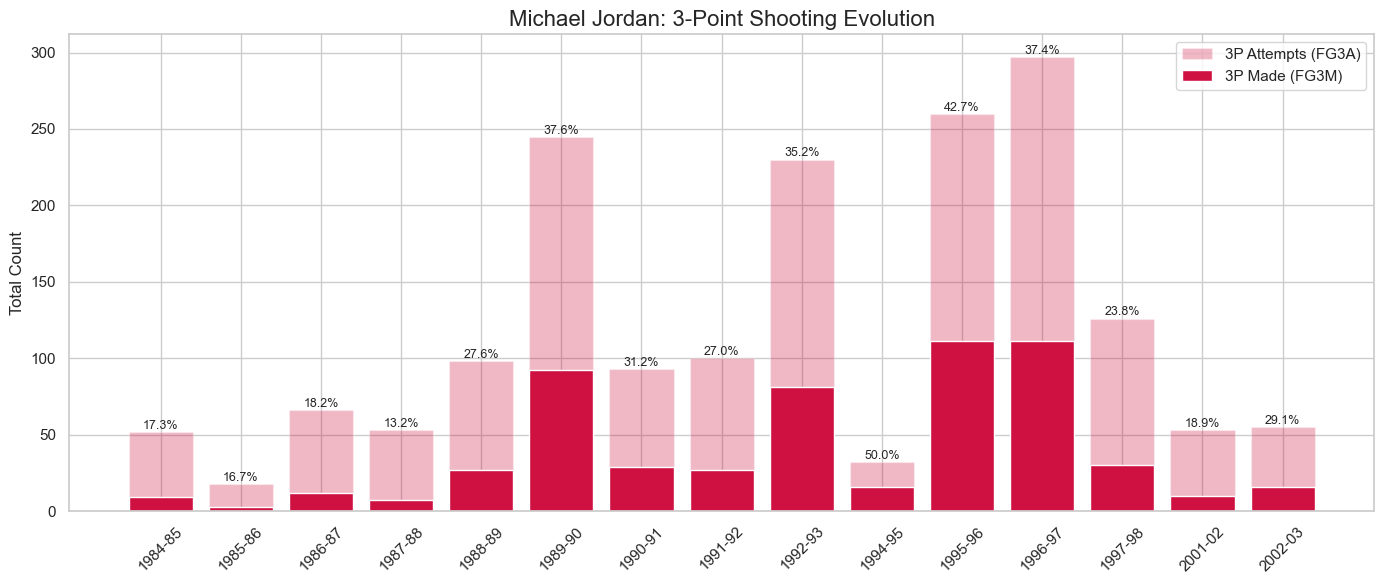

In [22]:
# 1. Pull Jordan's Raw Stats
mj_raw = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[0]

# 2. Select 3PT Columns
# FG3M = 3pt Made, FG3A = 3pt Attempts, FG3_PCT = 3pt %
mj_3pt = mj_raw[['SEASON_ID', 'FG3M', 'FG3A', 'FG3_PCT']].copy()

# 3. Print the Table
print("--- Michael Jordan: Career 3-Point Shooting ---")
print(mj_3pt.to_string(index=False))

# 4. Create the Plot
plt.figure(figsize=(14, 6))

# We use a line plot for 3PT% and bars for volume
plt.bar(mj_3pt['SEASON_ID'], mj_3pt['FG3A'], label='3P Attempts (FG3A)', color='#CE1141', alpha=0.3)
plt.bar(mj_3pt['SEASON_ID'], mj_3pt['FG3M'], label='3P Made (FG3M)', color='#CE1141')

plt.title('Michael Jordan: 3-Point Shooting Evolution', fontsize=16)
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend()

# Adding the percentage labels
for i, pct in enumerate(mj_3pt['FG3_PCT']):
    plt.text(i, mj_3pt['FG3A'][i] + 2, f'{pct*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- LeBron James: Career 3-Point Shooting ---
SEASON_ID  FG3M  FG3A  FG3_PCT
  2003-04    63   217    0.290
  2004-05   108   308    0.351
  2005-06   127   379    0.335
  2006-07    99   310    0.319
  2007-08   113   359    0.315
  2008-09   132   384    0.344
  2009-10   129   387    0.333
  2010-11    92   279    0.330
  2011-12    54   149    0.362
  2012-13   103   254    0.406
  2013-14   116   306    0.379
  2014-15   120   339    0.354
  2015-16    87   282    0.309
  2016-17   124   342    0.363
  2017-18   149   406    0.367
  2018-19   111   327    0.339
  2019-20   148   425    0.348
  2020-21   104   285    0.365
  2021-22   161   448    0.359
  2022-23   121   377    0.321
  2023-24   149   363    0.410
  2024-25   149   396    0.376
  2025-26    23    73    0.315


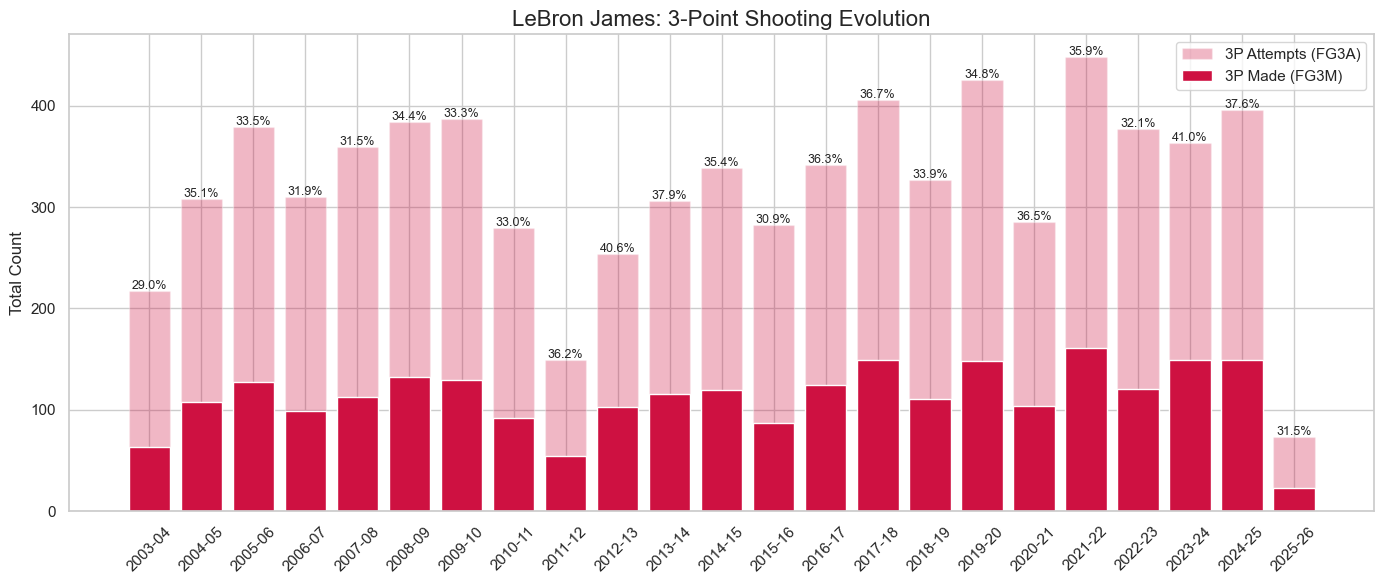

In [23]:
# 1. Pull Jordan's Raw Stats
lbj_raw = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[0]

# 2. Select 3PT Columns
# FG3M = 3pt Made, FG3A = 3pt Attempts, FG3_PCT = 3pt %
lbj_3pt = lbj_raw[['SEASON_ID', 'FG3M', 'FG3A', 'FG3_PCT']].copy()

# 3. Print the Table
print("--- LeBron James: Career 3-Point Shooting ---")
print(lbj_3pt.to_string(index=False))

# 4. Create the Plot
plt.figure(figsize=(14, 6))

# We use a line plot for 3PT% and bars for volume
plt.bar(lbj_3pt['SEASON_ID'], lbj_3pt['FG3A'], label='3P Attempts (FG3A)', color='#CE1141', alpha=0.3)
plt.bar(lbj_3pt['SEASON_ID'], lbj_3pt['FG3M'], label='3P Made (FG3M)', color='#CE1141')

plt.title('LeBron James: 3-Point Shooting Evolution', fontsize=16)
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.legend()

# Adding the percentage labels
for i, pct in enumerate(lbj_3pt['FG3_PCT']):
    plt.text(i, lbj_3pt['FG3A'][i] + 2, f'{pct*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

--- Michael Jordan: 3PT Per 100 ---
SEASON_ID  3PM_100  3PA_100  FG3_PCT
  1984-85 0.148545 0.858263    0.173
  1985-86 0.345179 2.071073    0.167
  1986-87 0.189791 1.043848    0.182
  1987-88 0.109708 0.830646    0.132
  1988-89 0.430440 1.562337    0.276
  1989-90 1.493292 3.976701    0.376
  1990-91 0.496000 1.590622    0.312
  1991-92 0.451670 1.672853    0.270
  1992-93 1.370474 3.891469    0.352
  1994-95 1.242920 2.485839    0.500
  1995-96 1.864078 4.366308    0.427
  1996-97 1.852686 4.957186    0.374
  1997-98 0.489392 2.055447    0.238
  2001-02 0.248405 1.316549    0.189
  2002-03 0.273926 0.941621    0.291

--- LeBron James: 3PT Per 100 ---
SEASON_ID  3PM_100   3PA_100  FG3_PCT
  2003-04 0.974101  3.355238    0.290
  2004-05 1.537795  4.385564    0.351
  2005-06 1.822860  5.439874    0.335
  2006-07 1.497141  4.688017    0.319
  2007-08 1.800878  5.721372    0.315
  2008-09 2.085082  6.065692    0.344
  2009-10 2.098151  6.294453    0.333
  2010-11 1.448969  4.394155    0

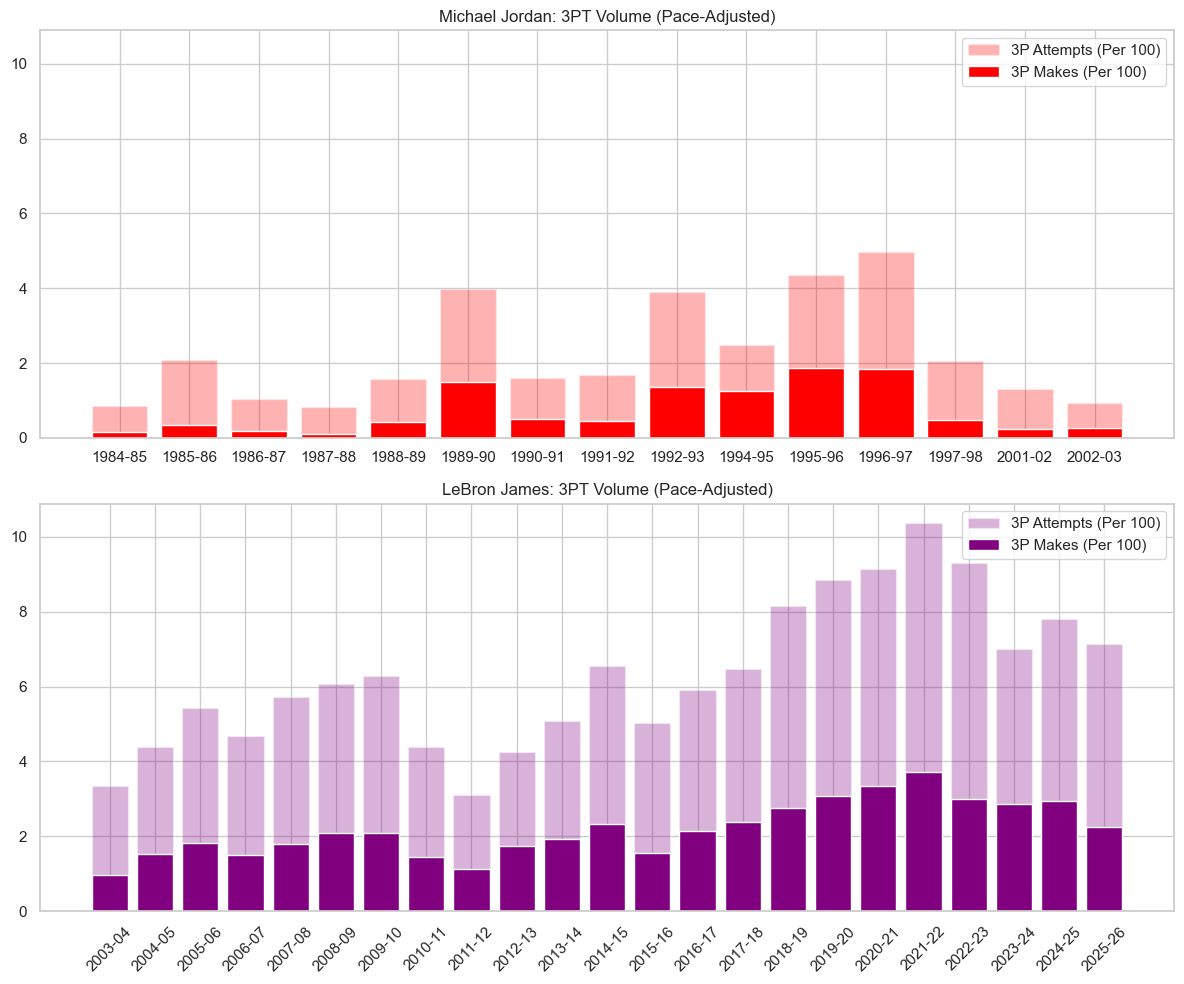

In [24]:
# 1. Fetch Career Stats (MJ: 893, LeBron: 2544)
mj_raw = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[0]
lbj_raw = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[0]

# 2. Define the Adjustment Function
# MJ Era Pace: ~92.5 | LeBron Era Pace: ~99.5
def get_3pt_100(df, era_pace):
    df = df.copy()
    # Formula: (Stat / Minutes) * 48 * (100 / Era Pace)
    df['3PM_100'] = (df['FG3M'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PA_100'] = (df['FG3A'] / df['MIN']) * 48 * (100 / era_pace)
    return df[['SEASON_ID', '3PM_100', '3PA_100', 'FG3_PCT']]

mj_100 = get_3pt_100(mj_raw, 92.5)
lbj_100 = get_3pt_100(lbj_raw, 99.5)

# 3. Print Tables for verification
print("--- Michael Jordan: 3PT Per 100 ---")
print(mj_100.to_string(index=False))
print("\n--- LeBron James: 3PT Per 100 ---")
print(lbj_100.to_string(index=False))

# 4. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# Michael Jordan Plot
ax1.bar(mj_100['SEASON_ID'], mj_100['3PA_100'], color='red', alpha=0.3, label='3P Attempts (Per 100)')
ax1.bar(mj_100['SEASON_ID'], mj_100['3PM_100'], color='red', label='3P Makes (Per 100)')
ax1.set_title('Michael Jordan: 3PT Volume (Pace-Adjusted)')
ax1.legend()

# LeBron James Plot
ax2.bar(lbj_100['SEASON_ID'], lbj_100['3PA_100'], color='purple', alpha=0.3, label='3P Attempts (Per 100)')
ax2.bar(lbj_100['SEASON_ID'], lbj_100['3PM_100'], color='purple', label='3P Makes (Per 100)')
ax2.set_title('LeBron James: 3PT Volume (Pace-Adjusted)')
ax2.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# 1. Fetch Career Stats
mj_raw = playercareerstats.PlayerCareerStats(player_id='893').get_data_frames()[0]
lbj_raw = playercareerstats.PlayerCareerStats(player_id='2544').get_data_frames()[0]

# 2. Adjustment Function (Per 100 Possessions)
def get_stats_100(df, era_pace):
    df = df.copy()
    # Normalize key metrics to 100 possessions
    df['PTS_100'] = (df['PTS'] / df['MIN']) * 48 * (100 / era_pace)
    df['FGA_100'] = (df['FGA'] / df['MIN']) * 48 * (100 / era_pace)
    df['FGM_100'] = (df['FGM'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PA_100'] = (df['FG3A'] / df['MIN']) * 48 * (100 / era_pace)
    df['3PM_100'] = (df['FG3M'] / df['MIN']) * 48 * (100 / era_pace)
    return df[['PTS_100', 'FGA_100', 'FGM_100', '3PA_100', '3PM_100', 'FG_PCT', 'FG3_PCT']]

mj_100 = get_stats_100(mj_raw, 92.5)
lbj_100 = get_stats_100(lbj_raw, 99.5)

# 3. Calculate Mean and Standard Deviation
def calculate_summary(df, name):
    mean = df.mean()
    std = df.std()
    
    summary = pd.DataFrame({
        'Metric': mean.index,
        f'{name} Mean': mean.values,
        f'{name} Std Dev': std.values
    })
    return summary

mj_summary = calculate_summary(mj_100, "Jordan")
lbj_summary = calculate_summary(lbj_100, "LeBron")

# 4. Merge and Display
final_comparison = pd.merge(mj_summary, lbj_summary, on='Metric')

print("--- MJ vs LeBron: Consistency & Average Comparison ---")
# Rounding for readability
print(final_comparison.round(2).to_string(index=False))

# Optional: Print a specific insight about consistency
print(f"\nConsistency Insight: Jordan's FGA Std Dev is {final_comparison.iloc[1, 2]:.2f} "
      f"vs LeBron's {final_comparison.iloc[1, 4]:.2f}")

--- MJ vs LeBron: Consistency & Average Comparison ---
 Metric  Jordan Mean  Jordan Std Dev  LeBron Mean  LeBron Std Dev
PTS_100        40.72            5.27        34.52            2.97
FGA_100        31.47            3.02        25.07            1.92
FGM_100        15.35            1.74        12.72            1.17
3PA_100         2.24            1.38         6.28            1.96
3PM_100         0.73            0.64         2.19            0.73
 FG_PCT         0.49            0.04         0.51            0.03
FG3_PCT         0.28            0.11         0.35            0.03

Consistency Insight: Jordan's FGA Std Dev is 3.02 vs LeBron's 1.92
